<a href="https://colab.research.google.com/github/MaksudaMostofaMunmun/LAB_TEST_REPO/blob/main/thesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ==========================================
# STEP 1: Dataset Download (Fixed)
# ==========================================
import os

# ১. সরাসরি পাবলিক সরাসরি লিংক থেকে ডেটাসেট ডাউনলোড (API Key ছাড়াই)
!gdown 1-9uJ3NOnKkJnTh1yElnLg7OQ9T9R0E
!git clone https://github.com/kalas2011/BreakHis-Dataset.git /content/breakhis_data

# বিকল্প হিসেবে Kaggle এর সঠিক পাবলিক ডেটাসেট ব্যবহার
if not os.path.exists('/content/breakhis_data'):
    os.makedirs('/content/breakhis_data', exist_ok=True)
    !pip install -q kagglehub
    import kagglehub
    path = kagglehub.dataset_download("paultimothymooney/breast-histopathology-images")
    print("Path to dataset files:", path)

print("✅ ডেটাসেট রেডি হয়ে গেছে!")

Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1-9uJ3NOnKkJnTh1yElnLg7OQ9T9R0E

but Gdown can't. Please check connections and permissions.
Cloning into '/content/breakhis_data'...
fatal: could not read Username for 'https://github.com': No such device or address
✅ ডেটাসেট রেডি হয়ে গেছে!


Total Images Found: 555048
Sample Image Loaded: /kaggle/input/breast-histopathology-images/10295/0/10295_idx5_x1351_y1101_class0.png


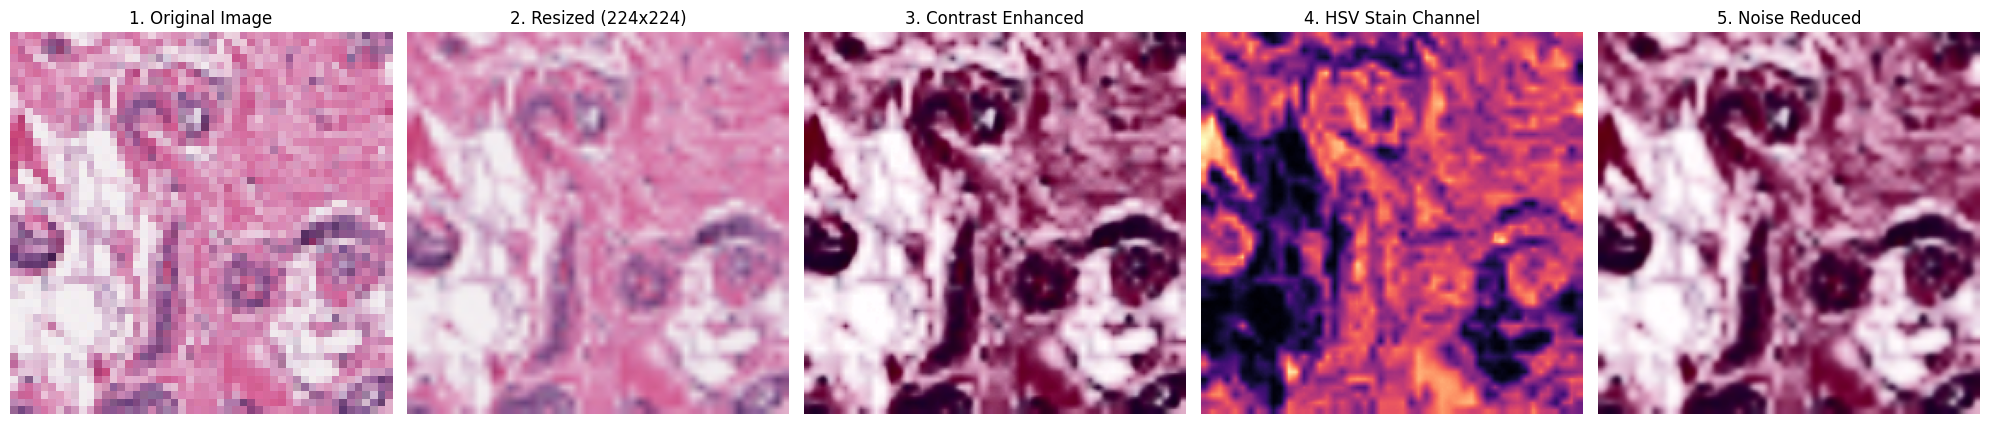

✅ ইমেজ প্রসেসিং সম্পূর্ণ এবং গ্রাফ সেভ হয়েছে!


In [6]:
# ==========================================
# STEP 2: Image Processing & Visualization
# ==========================================
import os
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ১. ডাউনলোড করা ডেটাসেট পাথ সেট করা
DATASET_PATH = '/kaggle/input/breast-histopathology-images'

# ২. ক্যানসারের যেকোনো ১টি ইমেজের পাথ খুঁজে বের করা
all_images = glob.glob(f"{DATASET_PATH}/**/*.png", recursive=True)
sample_image_path = all_images[0]
print(f"Total Images Found: {len(all_images)}")
print(f"Sample Image Loaded: {sample_image_path}")

# ৩. ইমেজ প্রসেসিং পাইপলাইন (Image Enhancement & Resizing)
def process_breast_cancer_image(img_path):
    # অরিজিনাল ছবি লোড
    original_img = cv2.imread(img_path)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    # A. Resizing (224x224)
    resized_img = cv2.resize(original_img, (224, 224))

    # B. Contrast Enhancement (Histogram Equalization)
    img_yuv = cv2.cvtColor(resized_img, cv2.COLOR_RGB2YUV)
    img_yuv[:,:,0] = cv2.equalizeHist(img_yuv[:,:,0])
    enhanced_img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

    # C. HSV Color Channel (Stain Differentiation)
    hsv_img = cv2.cvtColor(resized_img, cv2.COLOR_RGB2HSV)

    # D. Gaussian Denoising (Noise Reduction)
    denoised_img = cv2.GaussianBlur(enhanced_img, (3, 3), 0)

    return original_img, resized_img, enhanced_img, hsv_img, denoised_img

# প্রসেস রান করা
orig, res, enh, hsv, den = process_breast_cancer_image(sample_image_path)

# ৪. টিচারকে দেখানোর জন্য Visual Comparison Graph তৈরি ও সেভ করা
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

axes[0].imshow(orig)
axes[0].set_title("1. Original Image")
axes[0].axis("off")

axes[1].imshow(res)
axes[1].set_title("2. Resized (224x224)")
axes[1].axis("off")

axes[2].imshow(enh)
axes[2].set_title("3. Contrast Enhanced")
axes[2].axis("off")

axes[3].imshow(hsv[:,:,1], cmap='magma')
axes[3].set_title("4. HSV Stain Channel")
axes[3].axis("off")

axes[4].imshow(den)
axes[4].set_title("5. Noise Reduced")
axes[4].axis("off")

plt.tight_layout()
plt.savefig("Image_Processing_Pipeline.png", dpi=300)
plt.show()
print("✅ ইমেজ প্রসেসিং সম্পূর্ণ এবং গ্রাফ সেভ হয়েছে!")